In [1]:
from gerrytools.colors import DEFAULT_GREY, CITIZEN_BLUE, districtr

/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/gerrytools/__init__.py:9: UserWarning: pygeos support was removed in 1.0. geopandas.use_pygeos is a no-op and will be removed in geopandas 1.1.
  geopandas.options.use_pygeos = False


In [2]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import Axes

To improve the boxplot

- `boxplot_from_list`
- `boxplot_from_df`

Don't try to add the scatters -> this should be it's own thing

Make sure to allow for setting of the z-order

Values for the legend are okay


Better way of doing all of this is with a builder pattern

GerryPlot

-> save_to (dpi must be set at beginning will assume 300)

- Allow for the parsing of latex colors
- `add_boxplot` 
- `add_scatterplot`


In [3]:
def boxplot(
    ax,
    scores,
    xticklabels=None,
    labels=None,
    proposed_info={},
    percentiles=(1, 99),
    rotation=0,
    ticksize=12,
    jitter=1 / 3,
) -> Axes:
    r"""
    Plot boxplots, which takes `scores` — a dictionary where each value
    (corresponding to an ensemble, citizens' ensemble, or proposed plans),
    will be a list of lists, where each sublist will be its own box. Proposed
    scores will be plotted as colored circles on their respective box. Color the
    boxplots conditioned on the kind of the scores (ensemble or citizen), and
    trim each sublist to only the values between the specified percentiles.

    Args:
        ax (Axes): `Axes` object on which the boxplots are plotted.
        scores (dict): Dictionary with keys of `ensemble`, `citizen`, `proposed`
            which map to lists of numerical scores.
        proposed_info (dict, optional): Dictionary with keys of `colors`, `names`;
            the \(i\)th color in `color` corresponds to the \(i\)th name in `names`.
        percentiles (tuple, optional): Observations outside this range of
            percentiles are ignored. Defaults to `(1, 99)`, such that observations
            between the 1st and 99th percentiles (inclusive) are included, and
            all others are ignored.
        rotation (float, optional): Tick labels are rotated `rotation` degrees
            _counterclockwise_.
        ticksize (float, optional): Font size for tick labels.
        jitter (float, optional): When there is more than one proposed plan,
            adjust its detail points by a value drawn from \(\mathcal U (-\epsilon,
            \epsilon)\) where \(\epsilon = \) `jitter`.
        labels (list, optional): x- and y-axis labels, if desired.
        xticklabels (list, optional): Labels for the boxes, default to integers.

    Returns:
        `Axes` object on which the violins are plotted.
    """
    # Get all the scores into one list; pick a face color.
    ensemble = scores["ensemble"] if "ensemble" in scores else scores["citizen"]
    facecolor = DEFAULT_GREY if "ensemble" in scores else CITIZEN_BLUE

    # Specify the boxplots' style.
    boxstyle = {
        "lw": 1 / 2,
        "color": facecolor,
    }

    # Plot boxplots.
    ax.boxplot(
        ensemble,
        whis=percentiles,
        boxprops=boxstyle,
        whiskerprops=boxstyle,
        capprops=boxstyle,
        medianprops=boxstyle,
        showfliers=False,
    )

    # Set xticks, xlabels, and x-axis limits
    if not xticklabels:
        xticklabels = range(1, len(scores["ensemble"]) + 1)
    ax.set_xticks(range(1, len(ensemble) + 1))
    ax.set_xticklabels(xticklabels, fontsize=ticksize, rotation=rotation)
    ax.set_xlim(0.5, len(ensemble) + 0.5)

    # Plot each proposed plan individually, adjusting its detail points by
    # a value drawn from the uniform distribution of specified width centered on
    # the index of the violin.
    if "proposed" in scores:
        for boxplot in range(len(scores["proposed"])):
            for plan, score in enumerate(scores["proposed"][boxplot]):
                # Horizontally jitter proposed scores if there are multiple scores
                # at the same height.
                jitter_val = (
                    random.uniform(-jitter, jitter)
                    if scores["proposed"][boxplot].count(score) > 1
                    else 0
                )
                color_val = ""
                if "colors" in scores["proposed"]:
                    color_val = scores["proposed"]["colors"][boxplot]
                else:
                    color_val = districtr(plan + 1).pop()
                ax.scatter(
                    boxplot + 1 + jitter_val,
                    score,
                    color=color_val,
                    edgecolor="black",
                    s=100,
                    alpha=0.9,
                    label=proposed_info["names"][plan] if boxplot == 0 else None,
                )
        ax.legend()

    if labels:
        ax.set_xlabel(labels[0], fontsize=24)
        ax.set_ylabel(labels[1], fontsize=24)

    return ax


In [4]:
import numpy as np
def make_ensemble_boxes(n_boxes=4, n_per_box=200, seed=0):
    rng = np.random.default_rng(seed)
    boxes = []
    for j in range(n_boxes):
        # Different center/spread per box + a couple outliers so percentile trimming is meaningful
        x = rng.normal(loc=0.20 + 0.08*j, scale=0.06 + 0.01*j, size=n_per_box)
        x = np.clip(x, 0, 1)
        x = np.concatenate([x, [0.0, 1.0]])  # outliers
        boxes.append(x.tolist())
    return boxes

def make_citizen_boxes(n_boxes=3, n_per_box=150, seed=1):
    rng = np.random.default_rng(seed)
    boxes = []
    for j in range(n_boxes):
        x = rng.beta(a=2+j, b=5, size=n_per_box)  # bounded in [0,1]
        boxes.append(x.tolist())
    return boxes

# Proposed scores: a list-of-lists where each sublist corresponds to a box,
# and each entry within is a plan's score for that box.
def make_proposed_for_boxes(n_boxes=4):
    # 2 proposed plans across all boxes; include duplicates in box 1 to trigger jitter.
    return [
        [0.18, 0.18],  # duplicate -> jitter branch triggers
        [0.31, 0.37],
        [0.46, 0.44],
        [0.55, 0.63],
    ][:n_boxes]

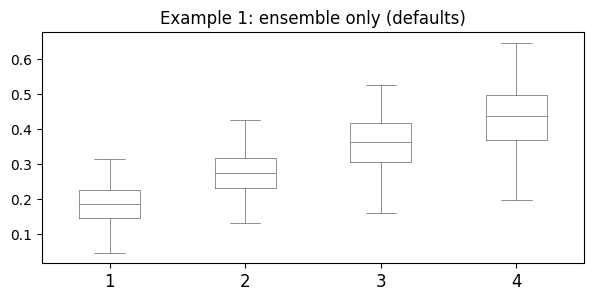

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
scores1 = {"ensemble": make_ensemble_boxes(n_boxes=4, seed=10)}
boxplot(ax, scores1)
ax.set_title("Example 1: ensemble only (defaults)")
plt.show()


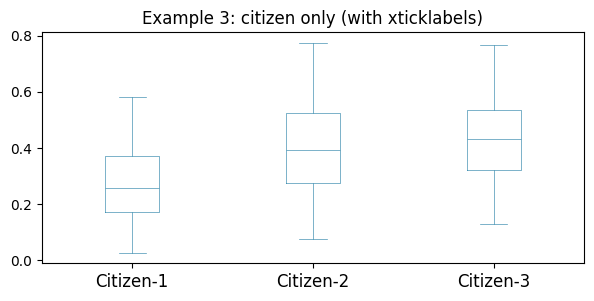

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
scores3 = {"citizen": make_citizen_boxes(n_boxes=3, seed=12)}
boxplot(
    ax,
    scores3,
    xticklabels=["Citizen-1", "Citizen-2", "Citizen-3"],  # needed due to bug noted below
)
ax.set_title("Example 3: citizen only (with xticklabels)")
plt.show()

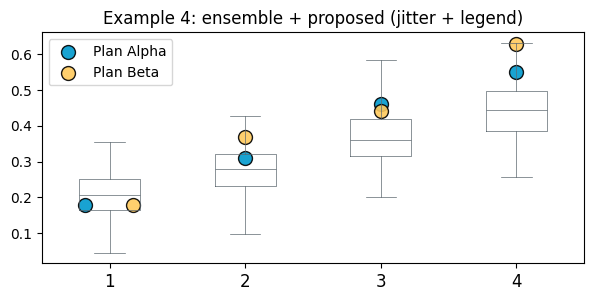

In [7]:
import random
random.seed(1)
np.random.seed(1)
fig, ax = plt.subplots(figsize=(7, 3))
scores4 = {
    "ensemble": make_ensemble_boxes(n_boxes=4, seed=13),
    "proposed": make_proposed_for_boxes(n_boxes=4),
}
proposed_info4 = {"names": ["Plan Alpha", "Plan Beta"]}  # must exist if proposed exists
boxplot(ax, scores4, proposed_info=proposed_info4, jitter=0.25)
ax.set_title("Example 4: ensemble + proposed (jitter + legend)")
plt.show()

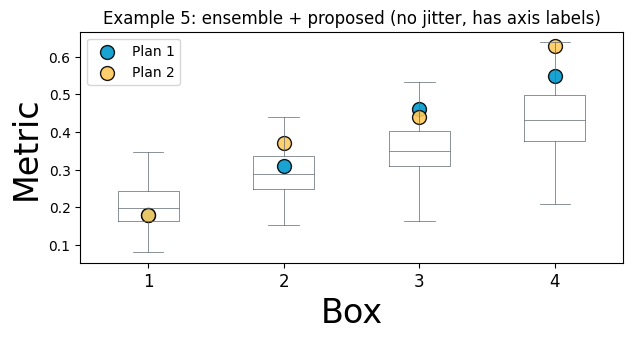

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
scores5 = {
    "ensemble": make_ensemble_boxes(n_boxes=4, seed=14),
    "proposed": make_proposed_for_boxes(n_boxes=4),
}
proposed_info5 = {"names": ["Plan 1", "Plan 2"]}
boxplot(ax, scores5, proposed_info=proposed_info5, labels=["Box", "Metric"], jitter=0.0)
ax.set_title("Example 5: ensemble + proposed (no jitter, has axis labels)")
plt.show()

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
scores6a = {
    "ensemble": make_ensemble_boxes(n_boxes=2, seed=15),
    "proposed": [[0.2, 0.3], [0.4, 0.5]],
}
try:
    boxplot(ax, scores6a)  # proposed_info defaults to {} -> KeyError on proposed_info["names"]
except Exception as e:
    print("Example 6A expected failure:", repr(e))
plt.close(fig)

Example 6A expected failure: KeyError('names')


In [10]:
from gerrytools.plotting.utils import sort_elections

def sealevel(ax, scores, num_districts, proposed_info, ticksize=12) -> Axes:
    r"""
    Plot a sea level plot: Each plan is a line across our elections on the
    x-axis, with Democratic vote share on the y-axis. The statewide Dem. vote
    share (proportionality) is plotted as a thick blue line.

    Args:
        ax (Axes): `Axes` object on which the sea level plot is plotted.
        scores (dict): Dictionary with keys of each plan plus a `statewide` key
            for proportionality. Each value is another dictionary, with keys for
            each election, values are the # seats.
        proposed_info (dict, optional): Dictionary with keys of `colors`, `names`;
            the \(i\)th color in `color` corresponds to the \(i\)th name in `names`.
        ticksize (float, optional): Font size for tick labels.
    """
    assert "statewide" in scores
    elections = sort_elections(scores["statewide"].keys())
    shares_by_plan = {plan: [] for plan in scores}
    for plan in scores:
        for election in elections:
            shares_by_plan[plan].append(scores[plan][election])

    ax.plot(
        shares_by_plan["statewide"],
        marker="o",
        markersize=10,
        lw=5,
        label="Proportionality",
    )

    for i, plan in enumerate(proposed_info["names"]):
        for j in range(len(shares_by_plan[plan])):
            if len(set([shares_by_plan[plan][j] for plan in shares_by_plan.keys()])) > 1:
                jitter = random.uniform(-0.02, 0.02)
            else:
                0

            shares_by_plan[plan][j] = shares_by_plan[plan][j] + jitter

        ax.plot(
            shares_by_plan[plan],
            marker="o",
            linestyle="--",
            color=proposed_info["colors"][i],
            label=plan,
        )

    ax.legend()

    if num_districts <= 20:
        yticks = np.arange(0, 1 + 1 / num_districts, 1 / num_districts)
        yticklabels = [f"{i}/{num_districts}" for i in range(num_districts + 1)]
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

    ax.axhline(0.5, color=DEFAULT_GREY, label="50%")
    ax.set_xticks(range(len(elections)))
    ax.set_xticklabels(elections, fontsize=ticksize)
    ax.set_ylim(-0.02, 1)

    return ax

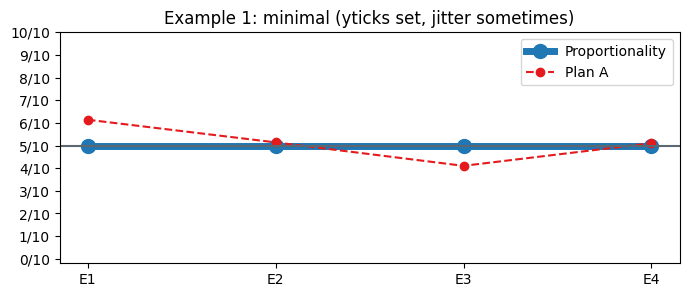

In [11]:

# Helper: build seat-share dicts
def seatshare_map(num_districts, **seats_by_election):
    return {k: v / num_districts for k, v in seats_by_election.items()}

# -----------------------------
# Example 1: Minimal “happy path”
# - has "statewide" (assert passes)
# - num_districts <= 20 -> ytick labels branch runs
# - jitter branch triggers (values differ across plans at some elections)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 3))
num_districts = 10

scores1 = {
    "statewide": seatshare_map(num_districts, E1=5, E2=5, E3=5, E4=5),
    "Plan A":    seatshare_map(num_districts, E1=6, E2=5, E3=4, E4=5),
}
proposed_info1 = {"names": ["Plan A"], "colors": ["#e41a1c"]}

random.seed(0)  # jitter reproducible
sealevel(ax, scores1, num_districts=num_districts, proposed_info=proposed_info1, ticksize=10)
ax.set_title("Example 1: minimal (yticks set, jitter sometimes)")
plt.show()

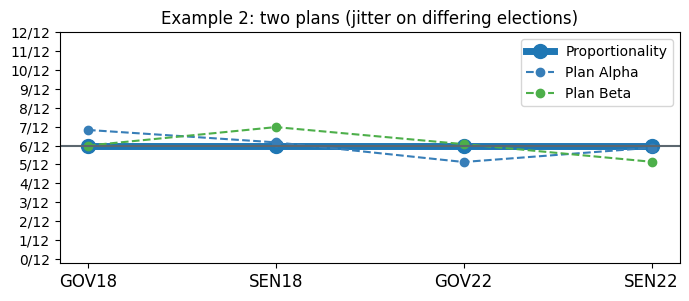

In [12]:


# -----------------------------
# Example 2: Two proposed plans + jitter clearly visible
# - multiple plans
# - jitter varies by election
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 3))
num_districts = 12

scores2 = {
    "statewide": seatshare_map(num_districts, GOV18=6, SEN18=6, GOV22=6, SEN22=6),
    "Plan Alpha": seatshare_map(num_districts, GOV18=7, SEN18=6, GOV22=5, SEN22=6),
    "Plan Beta":  seatshare_map(num_districts, GOV18=6, SEN18=7, GOV22=6, SEN22=5),
}
proposed_info2 = {
    "names": ["Plan Alpha", "Plan Beta"],
    "colors": ["#377eb8", "#4daf4a"],
}

random.seed(1)
sealevel(ax, scores2, num_districts=num_districts, proposed_info=proposed_info2)
ax.set_title("Example 2: two plans (jitter on differing elections)")
plt.show()



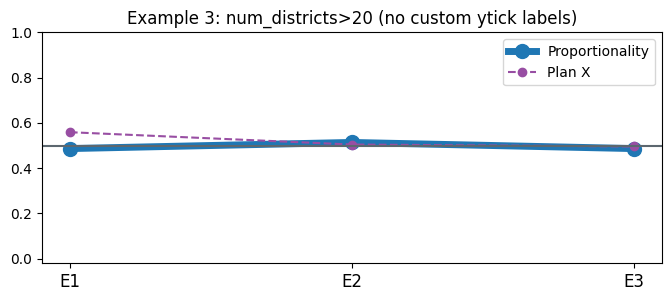

In [13]:

# -----------------------------
# Example 3: num_districts > 20 (skips ytick relabeling branch)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 3))
num_districts = 37

scores3 = {
    "statewide": seatshare_map(num_districts, E1=18, E2=19, E3=18),
    "Plan X":    seatshare_map(num_districts, E1=20, E2=18, E3=19),
}
proposed_info3 = {"names": ["Plan X"], "colors": ["#984ea3"]}

random.seed(2)
sealevel(ax, scores3, num_districts=num_districts, proposed_info=proposed_info3)
ax.set_title("Example 3: num_districts>20 (no custom ytick labels)")
plt.show()

In [14]:


# -----------------------------
# Example 4 (EXPECTED FAILURE): missing "statewide" -> assertion error
# -----------------------------
fig, ax = plt.subplots()
scores4 = {"Plan A": {"E1": 0.5}}
try:
    sealevel(ax, scores4, num_districts=10, proposed_info={"names":["Plan A"], "colors":["#e41a1c"]})
except Exception as e:
    print("Example 4 expected failure:", repr(e))
plt.close(fig)

Example 4 expected failure: AssertionError()


In [15]:

# -----------------------------
# Example 5 (EXPECTED FAILURE): plan missing an election key -> KeyError
# (statewide has E2 but Plan A doesn't)
# -----------------------------
fig, ax = plt.subplots()
scores5 = {
    "statewide": {"E1": 0.5, "E2": 0.5},
    "Plan A": {"E1": 0.6},
}
try:
    sealevel(ax, scores5, num_districts=10, proposed_info={"names":["Plan A"], "colors":["#e41a1c"]})
except Exception as e:
    print("Example 5 expected failure:", repr(e))
plt.close(fig)

# -----------------------------
# Example 6 (EXPECTED FAILURE): triggers the jitter bug (UnboundLocalError)
# If *all* plans have the same value at an election, your code hits `else: 0`
# (doesn't assign jitter), then tries to use `jitter` anyway.
# -----------------------------
fig, ax = plt.subplots()
scores6 = {
    "statewide": {"E1": 0.5, "E2": 0.5},
    "Plan A":    {"E1": 0.5, "E2": 0.5},  # identical everywhere -> jitter never assigned
}
try:
    sealevel(ax, scores6, num_districts=10, proposed_info={"names":["Plan A"], "colors":["#e41a1c"]})
except Exception as e:
    print("Example 6 expected failure (jitter bug):", repr(e))
plt.close(fig)

Example 5 expected failure: KeyError('E2')
Example 6 expected failure (jitter bug): UnboundLocalError("cannot access local variable 'jitter' where it is not associated with a value")


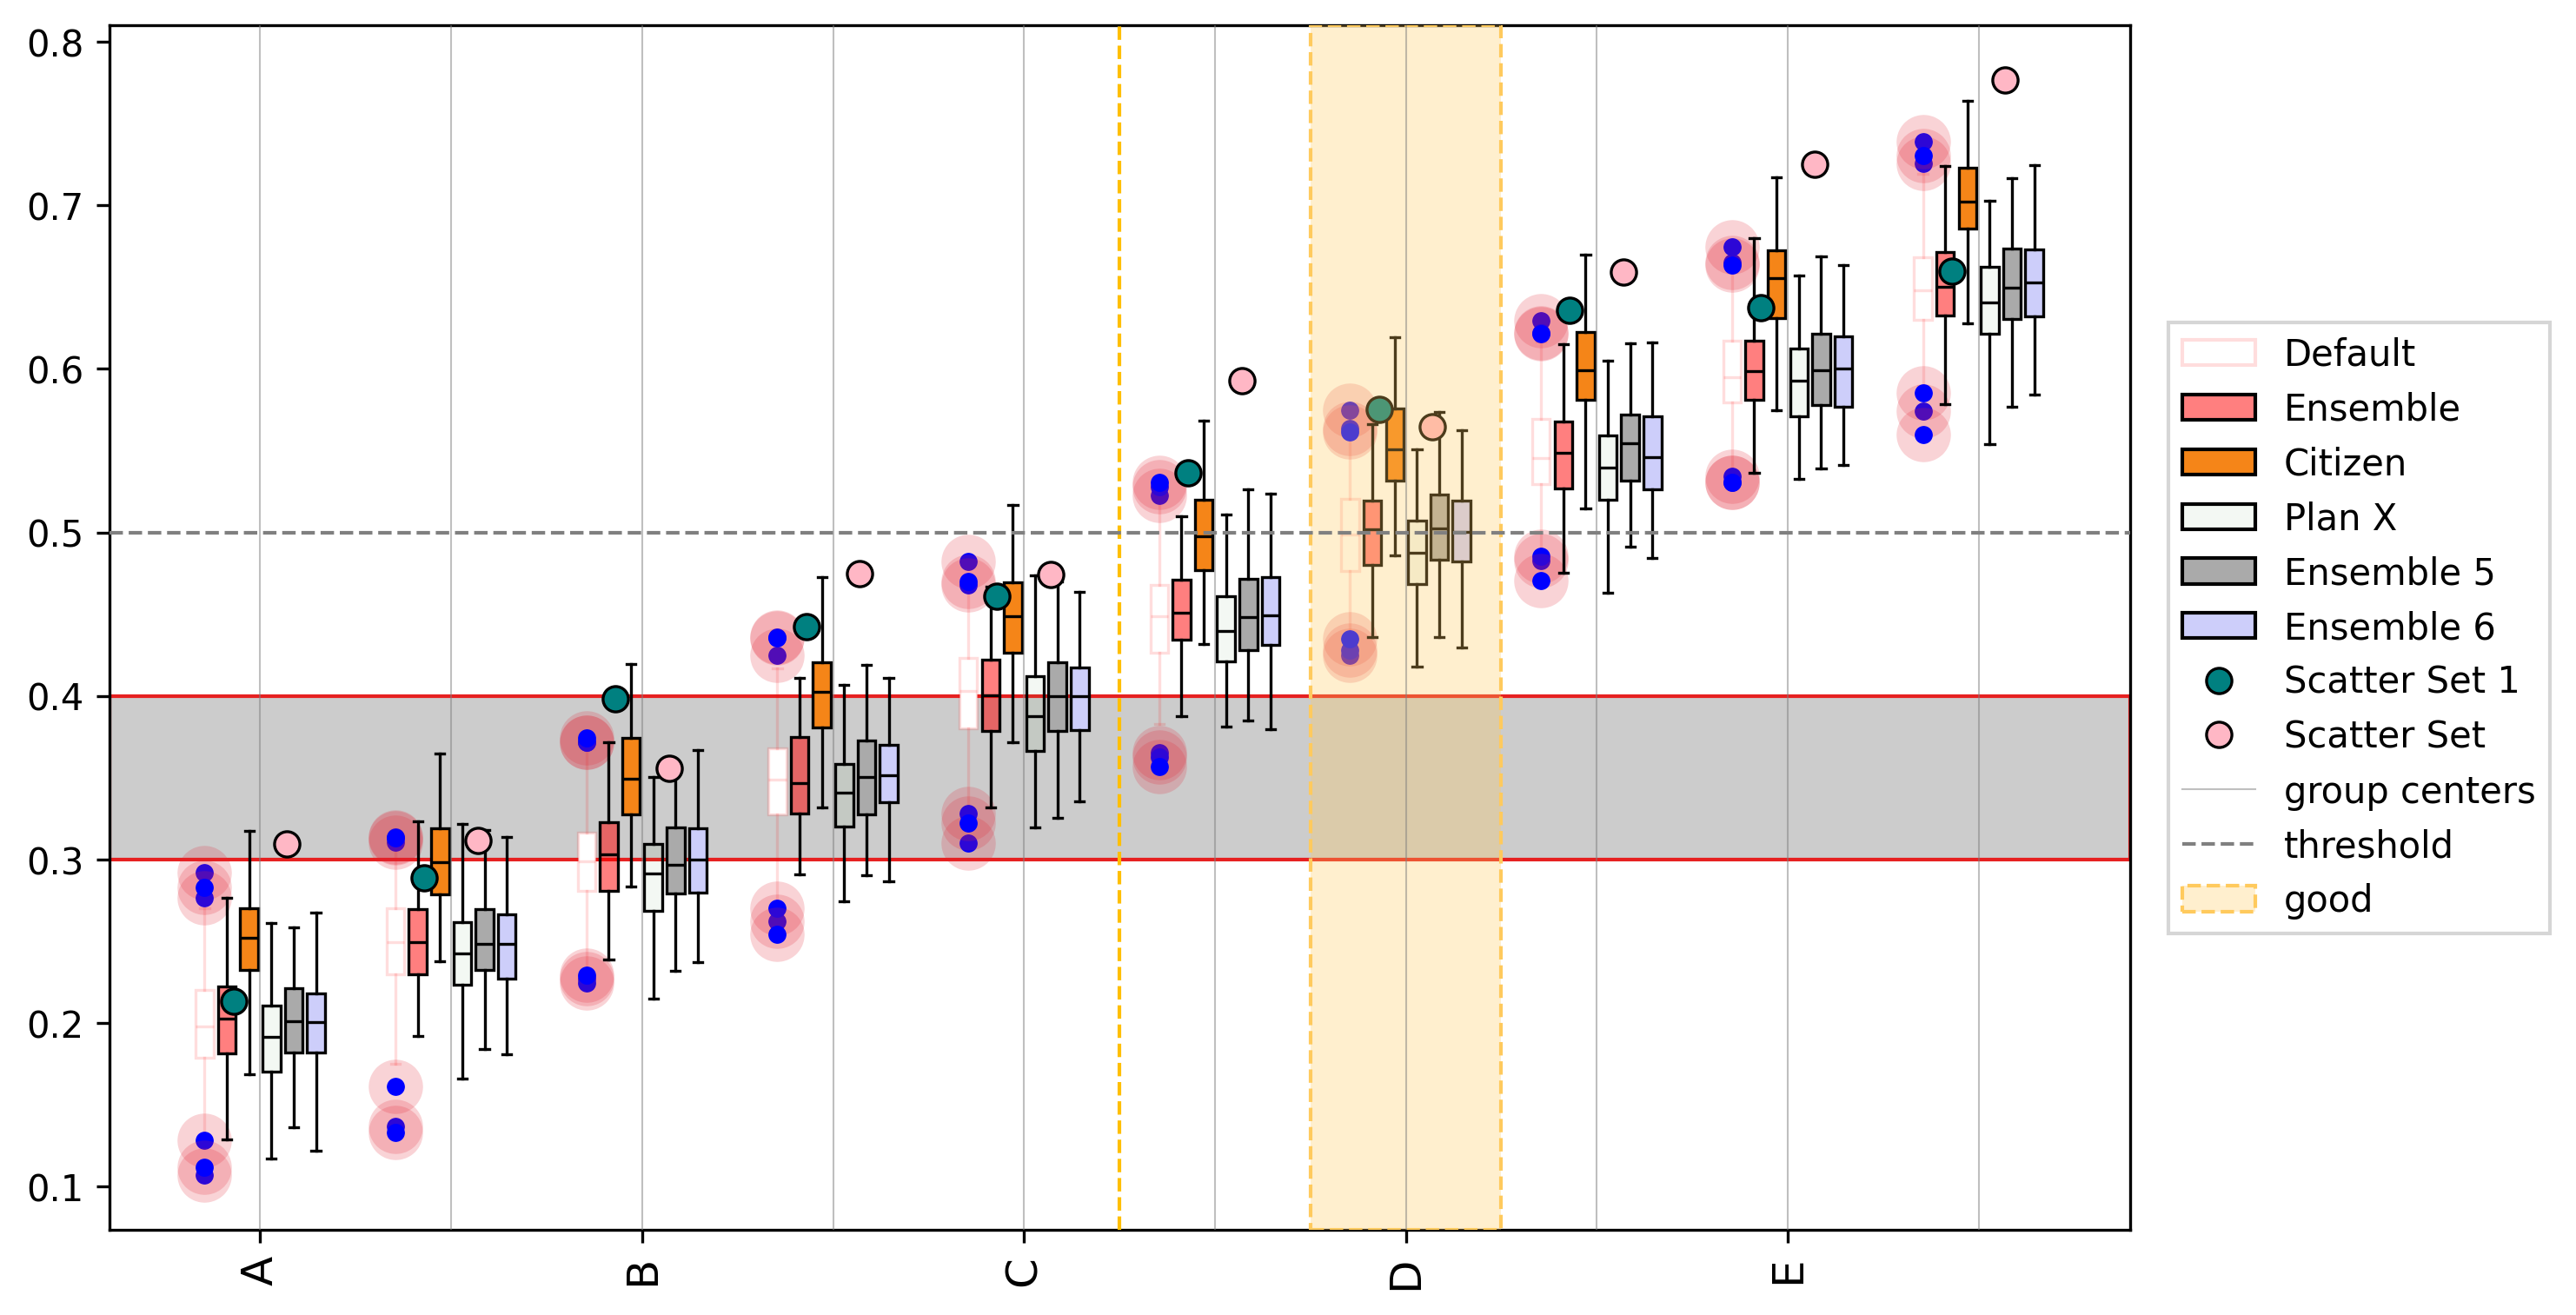

In [17]:
import numpy as np
from gerrytools.plotting.boxplot import BoxPlot
from gerrytools.plotting.gerryplot import PointMarkerSettings


rng = np.random.default_rng(0)
labels = [f"D{i}" for i in range(1, 11)]

def make_boxplot_set(mu_shift=0.0,sigma=0.03):
    total_datasets = len(labels)
    return {lab: (rng.normal(0.2 + i/(2*total_datasets) + mu_shift, sigma, 300)).tolist() for i, lab in enumerate(labels)}

def make_scatter_data(mu_shift=0.0, sigma=0.1):
    total_values = 10
    vals =  [rng.random()*sigma+mu_shift+i/(2*total_values) for i in range(total_values)]
    return vals

# dist = BoxPlot(include_legend=True)
dist = BoxPlot(include_legend=False, boxplot_group_width=0.7, boxplot_width_scale=0.8)

dist.add_boxplot_datasets(
    make_boxplot_set(0.00), 
    name="Default", 
    showfliers=True, 
    facecolor="white",
    fliersettings=PointMarkerSettings(
        markersize=5, 
        markerfacecolor="blue", 
        markerfacealpha=1,
        markeredgecolor="alizarin", 
        markeredgealpha=0.2,
        markeredgewidth=10.0,
        marker="o"
    ),
    edgecolor="#ff000022"
)
dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble", facecolor=(1, 0, 0, 0.1), percentiles=(1, 99), facealpha=0.5)
dist.add_boxplot_datasets(make_boxplot_set(0.05), name="Citizen",  facecolor="#f58518", percentiles=(1, 99))
# dist.add_boxplot_datasets(make_boxplot_set(-0.03), name="Plan X",  face_color="#54a24b", percentiles=(1, 99))
dist.add_boxplot_datasets(make_boxplot_set(-0.01), name="Plan X",  facecolor="#54a24b11", percentiles=(1, 99))
# dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble 2", face_color="purple!50", percentiles=(1, 99))
# dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble 3", face_color="blue!50!red", percentiles=(1, 99))
# dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble 4", face_color="green", percentiles=(1, 99))
dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble 5", facecolor="red!50!blue!67!green!50!white", percentiles=(1, 99))
dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble 6", facecolor="r!10!g!10!b!20", percentiles=(1, 99))
# dist.clear_xticks()
# dist.clear_yticks()
# dist.set_xaxis_fontsize(12)
# dist.hide_frame()
# dist.add_scatter_set(np.random.random(10)*0.5+0.3, name="Scatter Set 1", color="teal")
dist.add_pointset(make_scatter_data(0.2), name="Scatter Set 1", facecolor="teal")
dist.add_pointset(make_scatter_data(0.25), name="Scatter Set", facecolor="cherryblossompink")
dist.clear_vertical_lines_and_bands()

dist.add_vertical_lines(x_values=5.5, linecolor="amber", linestyle="--", linewidth=1)

dist.add_vertical_lines(x_values=list(range(1, 11)), linecolor="grey", linestyle="-", linewidth=0.5, linealpha=0.5, name="group centers")
dist.add_vertical_band(x_low=6.5, x_high=7.5, bandcolor="nacho", linestyle="--", linewidth=1, bandalpha = 0.3, name="good")
dist.add_horizontal_lines(y_values=0.5, linecolor="grey", linestyle="--", linewidth=1, name="threshold")
# dist.add_horizontal_band(y_low=0.3, y_high=0.4, bandcolor="lust", linestyle="--", linewidth=1)
dist.add_horizontal_band(y_low=0.3, y_high=0.4, linecolor = "lust", zorder=0)
# dist.show()
dist.set_xaxis_tick_style(size=12, rotation=90)
dist.update_xtick_values(locations=[1,3,5,7,9], labels=['A', 'B', 'C', 'D', 'E'])

# dist.save_legend("test_legend.png")
dist.save("test_boxplot.png")

In [ ]:
import numpy as np
from gerrytools.plotting.boxplot import BoxPlot
from gerrytools.plotting.gerryplot import PointMarkerSettings


rng = np.random.default_rng(0)
labels = [f"D{i}" for i in range(1, 11)]

def make_boxplot_set(mu_shift=0.0,sigma=0.03):
    total_datasets = len(labels)
    return {lab: (rng.normal(0.2 + i/(2*total_datasets) + mu_shift, sigma, 300)).tolist() for i, lab in enumerate(labels)}

def make_scatter_data(mu_shift=0.0, sigma=0.1):
    total_values = 10
    vals =  [rng.random()*sigma+mu_shift+i/(2*total_values) for i in range(total_values)]
    return vals

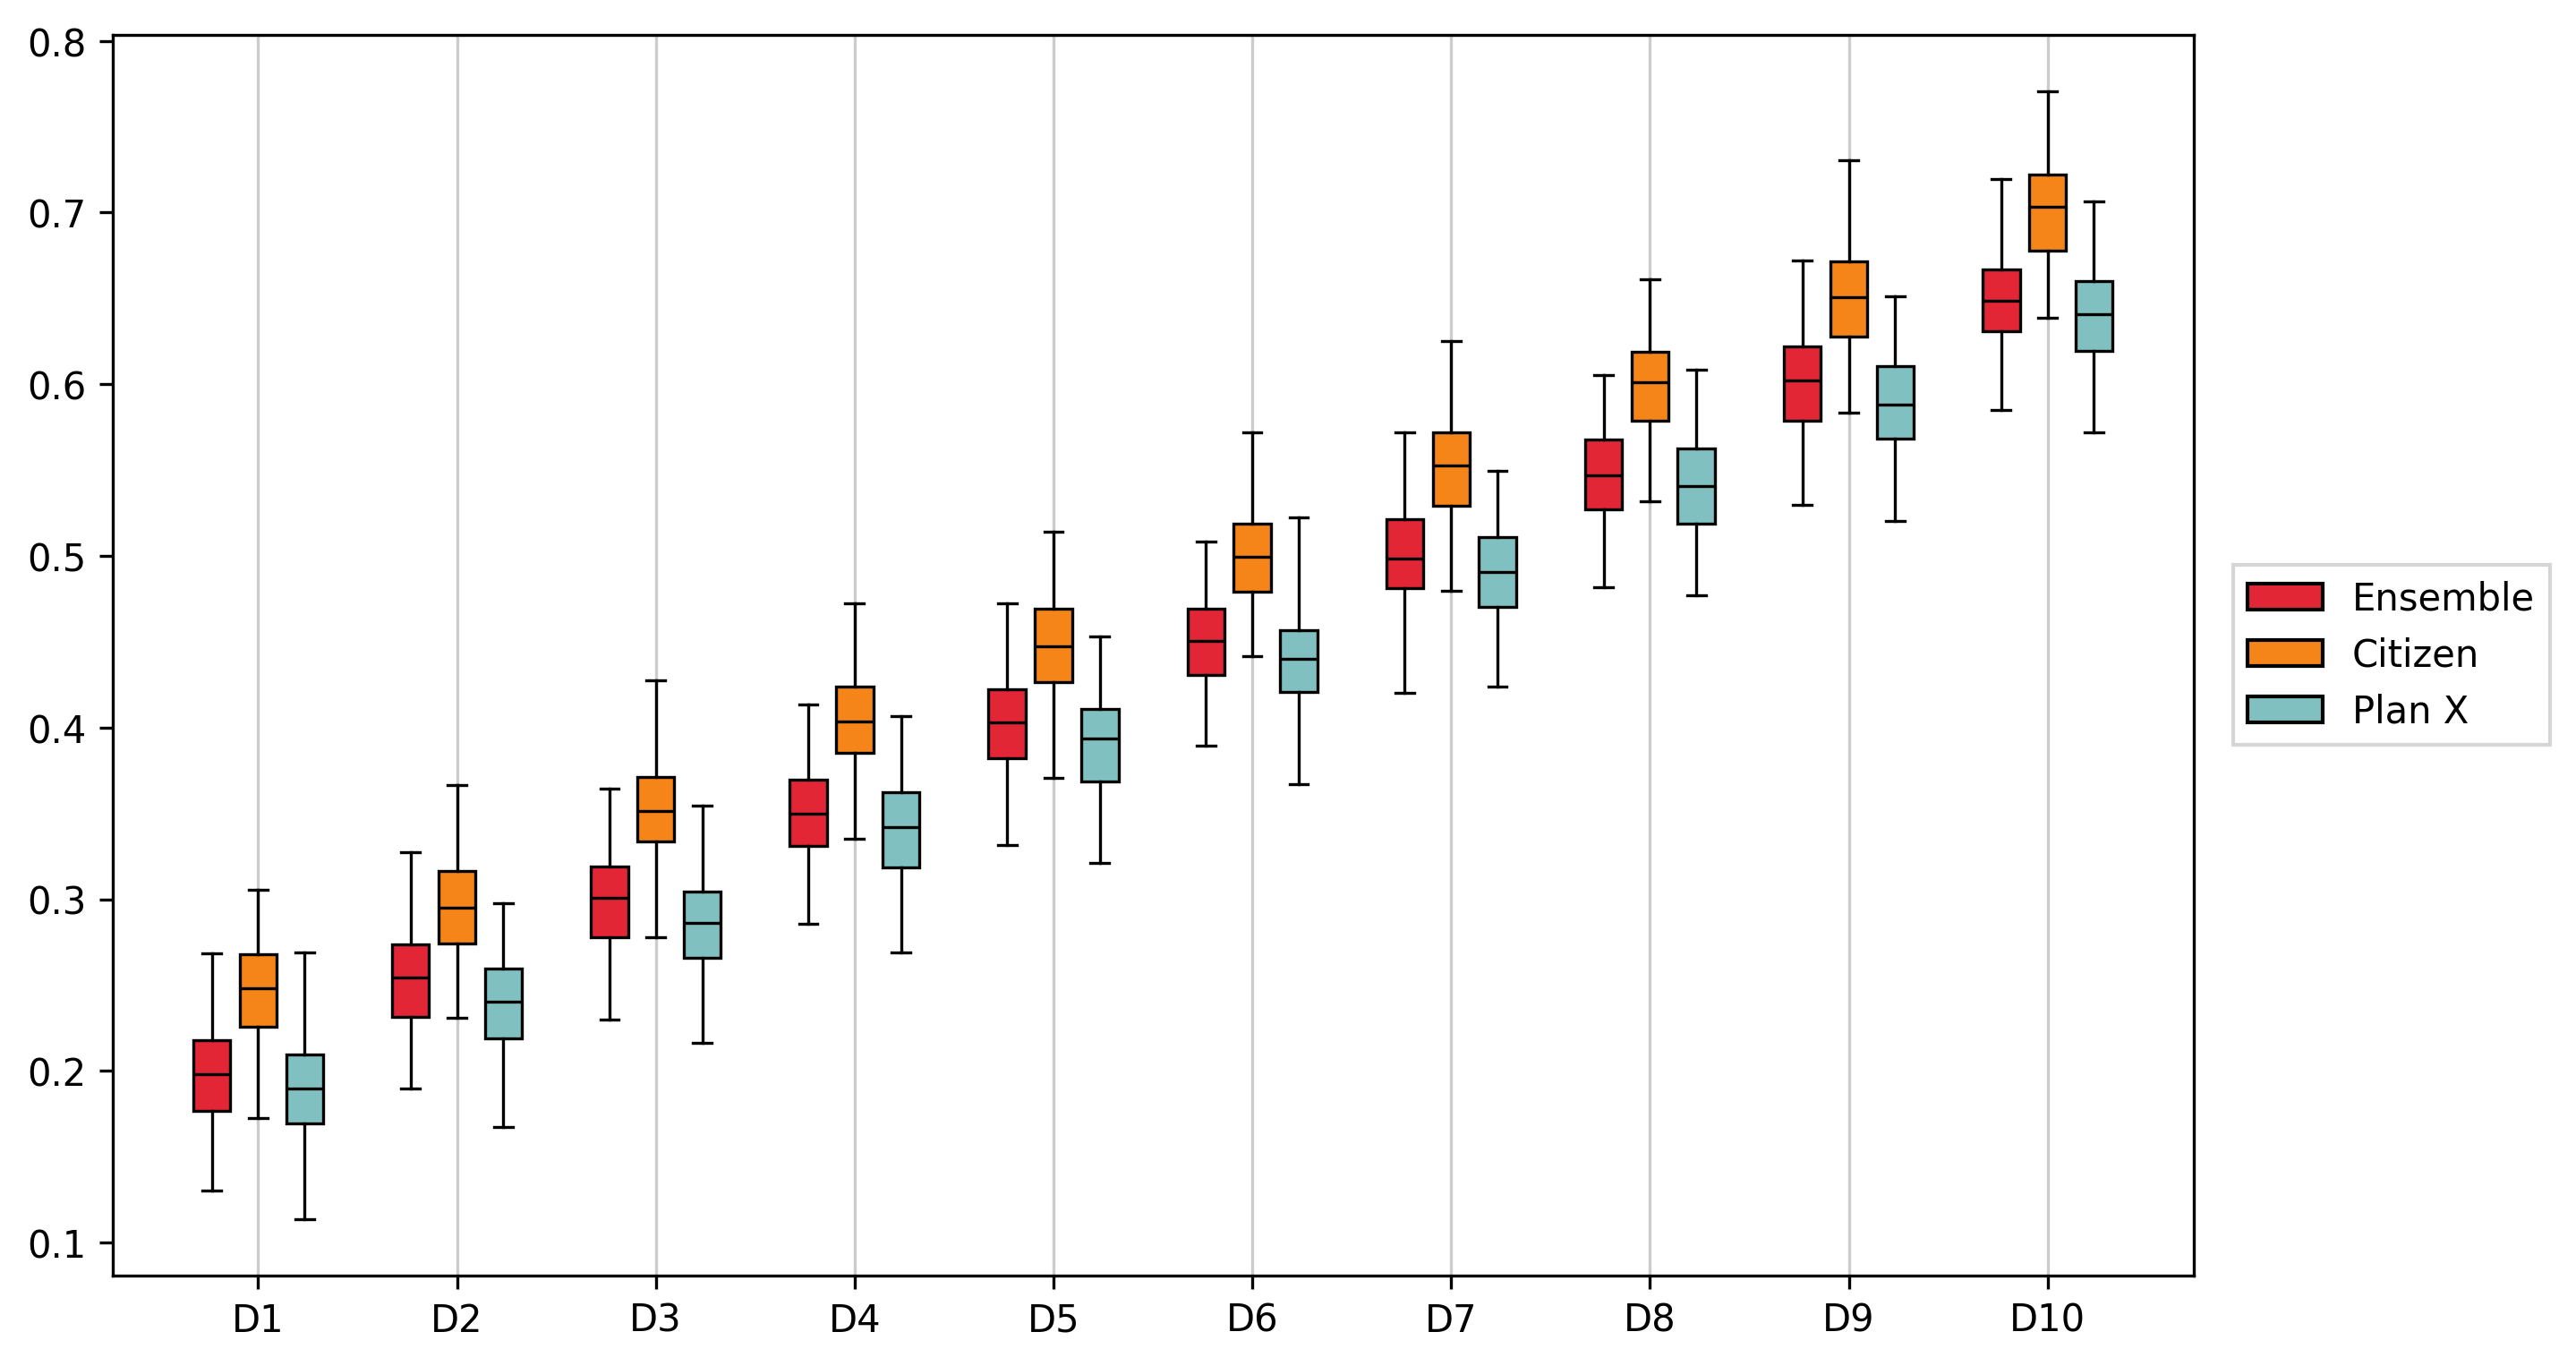

In [27]:
dist = BoxPlot(include_legend=False, boxplot_group_width=0.7, boxplot_width_scale=0.8)

dist.add_boxplot_datasets(make_boxplot_set(0.00), name="Ensemble", facecolor="alizarin", percentiles=(1, 99))
dist.add_boxplot_datasets(make_boxplot_set(0.05), name="Citizen",  facecolor="#f58518", percentiles=(1, 99))
dist.add_boxplot_datasets(make_boxplot_set(-0.01), name="Plan X",  facecolor="teal!50", percentiles=(1, 99))

dist.show()

/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/gerrytools/plotting/histogram.py:416: UserWarning: Outline histogram specified with facecolor != 'none'; setting facecolor to 'none'.
  warn(


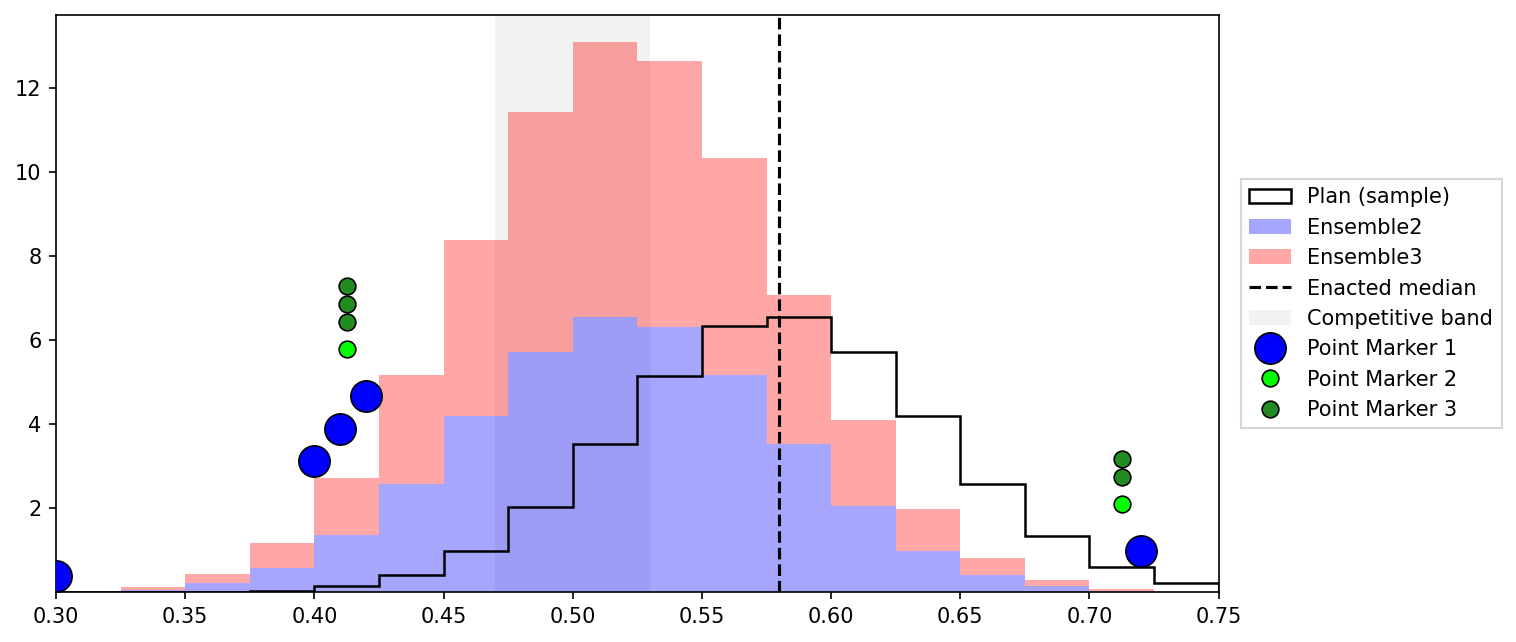

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from gerrytools.plotting.histogram import Histogram

# --- fake data (replace with your real series/arrays) ---
rng = np.random.default_rng(42)
nsamples = 4000000
# “ensemble-ish” distribution
ensemble = rng.normal(loc=0.52, scale=0.06, size=nsamples)
ensemble = np.clip(ensemble, 0, 1) 

# “plan-ish” single distribution (or just one value repeated)
# plan = rng.normal(loc=0.58, scale=0.02, size=300)
plan = rng.normal(loc=0.58, scale=0.06, size=nsamples)

# --- build plot ---
h = Histogram(
    figure_size=(10, 5),
    dpi=150,
    include_legend=True,
    grid=False,
)

# main filled histogram
# h.add_histogram(
#     ensemble,
#     name="Ensemble",
#     facecolor="ensemble:recoma",  # uses your color resolver
#     facealpha=0.35,
#     edgecolor="none",
#     density=False,
#     histtype="overlay",
# )

# # main filled histogram
# h.add_histogram(
#     ensemble,
#     name="Ensemble2",
#     facecolor="blue",  # uses your color resolver
#     facealpha=0.35,
#     edgecolor="none",
#     density=False,
#     histtype="weaved",
# )
# # main filled histogram
# h.add_histogram(
#     ensemble,
#     name="Ensemble3",
#     facecolor="red",  # uses your color resolver
#     facealpha=0.35,
#     edgecolor="none",
#     density=False,
#     histtype="weaved",
# )

# main filled histogram
h.add_histogram(
    ensemble,
    name="Ensemble2",
    facecolor="blue",  # uses your color resolver
    facealpha=0.35,
    # edgecolor="blue",
    # edgealpha=0.35,
    histtype="stack",
    linewidth=3,
)
# main filled histogram
h.add_histogram(
    ensemble,
    name="Ensemble3",
    facecolor="red",  # uses your color resolver
    facealpha=0.35,
    edgecolor="none",
    histtype="stack",
)






# outline histogram overlay
h.add_histogram(
    plan,
    name="Plan (sample)",
    facecolor="black",
    facealpha=1.0,
    edgecolor="black",
    edgealpha=1.0,
    linewidth=1.2,
    histtype="outline",
    zorder=4,
)

# mark a single “enacted plan” value
enacted_value = float(np.median(plan))
h.add_vertical_lines(
    enacted_value,
    linecolor="black",
    linealpha=1.0,
    linestyle="--",
    linewidth=1.5,
    zorder=10,
    name="Enacted median",
)

# a “competitive band” overlay
h.add_vertical_band(
    0.47,
    0.53,
    bandcolor="gainsboro",
    bandalpha=0.35,
    linecolor="none",
    zorder=-10,
    name="Competitive band",
)

# (optional) tighten x limits / ticks
h.set_xlimits(0.30, 0.75)
h.set_yaxis_tick_style(size=10)
h.set_xaxis_tick_style(size=10)
# h.update_ytick_values(locations=[], labels=[])
h.add_points_above([0.2, 0.3, 0.4,0.41,0.42, 0.72], centered_on_bin=False, facecolor="blue", markersize=15)
h.add_points_above([0.2, 0.3, 0.4, 0.72], centered_on_bin=True, facecolor="green", markersize=8, y_offset=0.5)
h.add_points_above([-200, 0.3, 0.4,0.42,0.41, 0.72, 0.72], centered_on_bin=True, facecolor="forestgreen", markersize=8, y_offset=0.2)
# h.add_points([0.2, 0.3, 0.4, 0.7, 0.5], centered=True, y_offset=0.1, facecolor="ensemble:recomb", markeredgewidth=1)
h.set_bins_by_width(0.03)
h.set_bins(np.arange(0, 1.05, 0.025))
h.transform_to_density()

h.show()


/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/gerrytools/plotting/histogram.py:408: UserWarning: Outline histogram specified with linewidth <= 0; setting linewidth to 0.8.
  warn(
/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/gerrytools/plotting/histogram.py:425: UserWarning: Outline histogram specified with edgecolor 'none'; setting edgecolor to 'black'.
  warn(


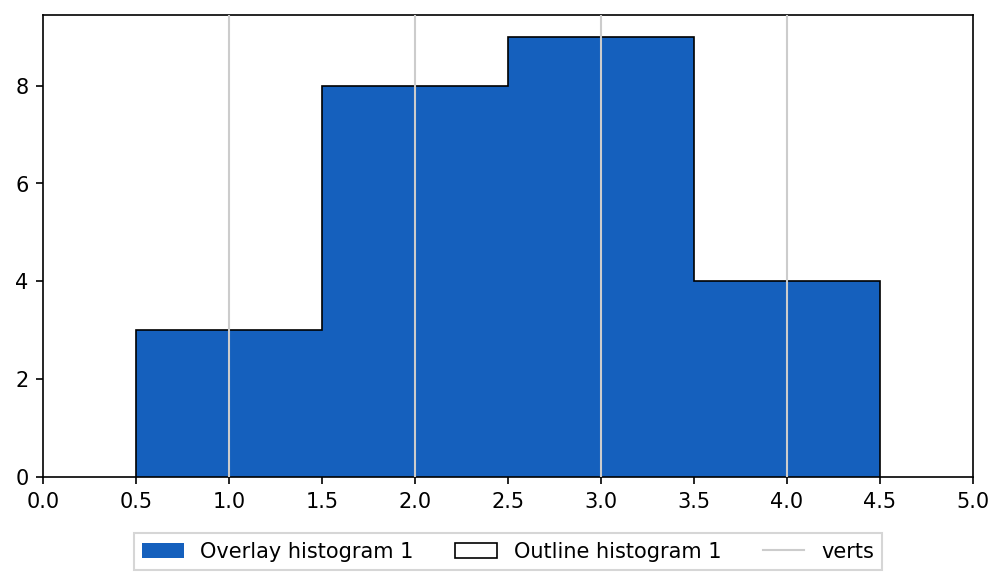

In [ ]:
hist = Histogram(figure_size=(8,4), dpi=150, include_legend=True)
hist.add_histogram(
    [1,1,2,2,2,2,2,2,3,3,2,2,3,3,3,3,3,3,3,4,4,4,4,1]
)
hist.add_histogram(
    [1,1,2,2,2,2,2,2,3,3,2,2,3,3,3,3,3,3,3,4,4,4,4,1], histtype="outline"
)

hist.set_bins_by_width(1)
hist.center_data_on_bin_edges()
hist.set_legend_options(
    loc="upper center",
    bbox_to_anchor=(0.5,-0.1),
    ncols=5
)
hist.add_vertical_lines([1,2,3,4], name='verts')
hist.show()

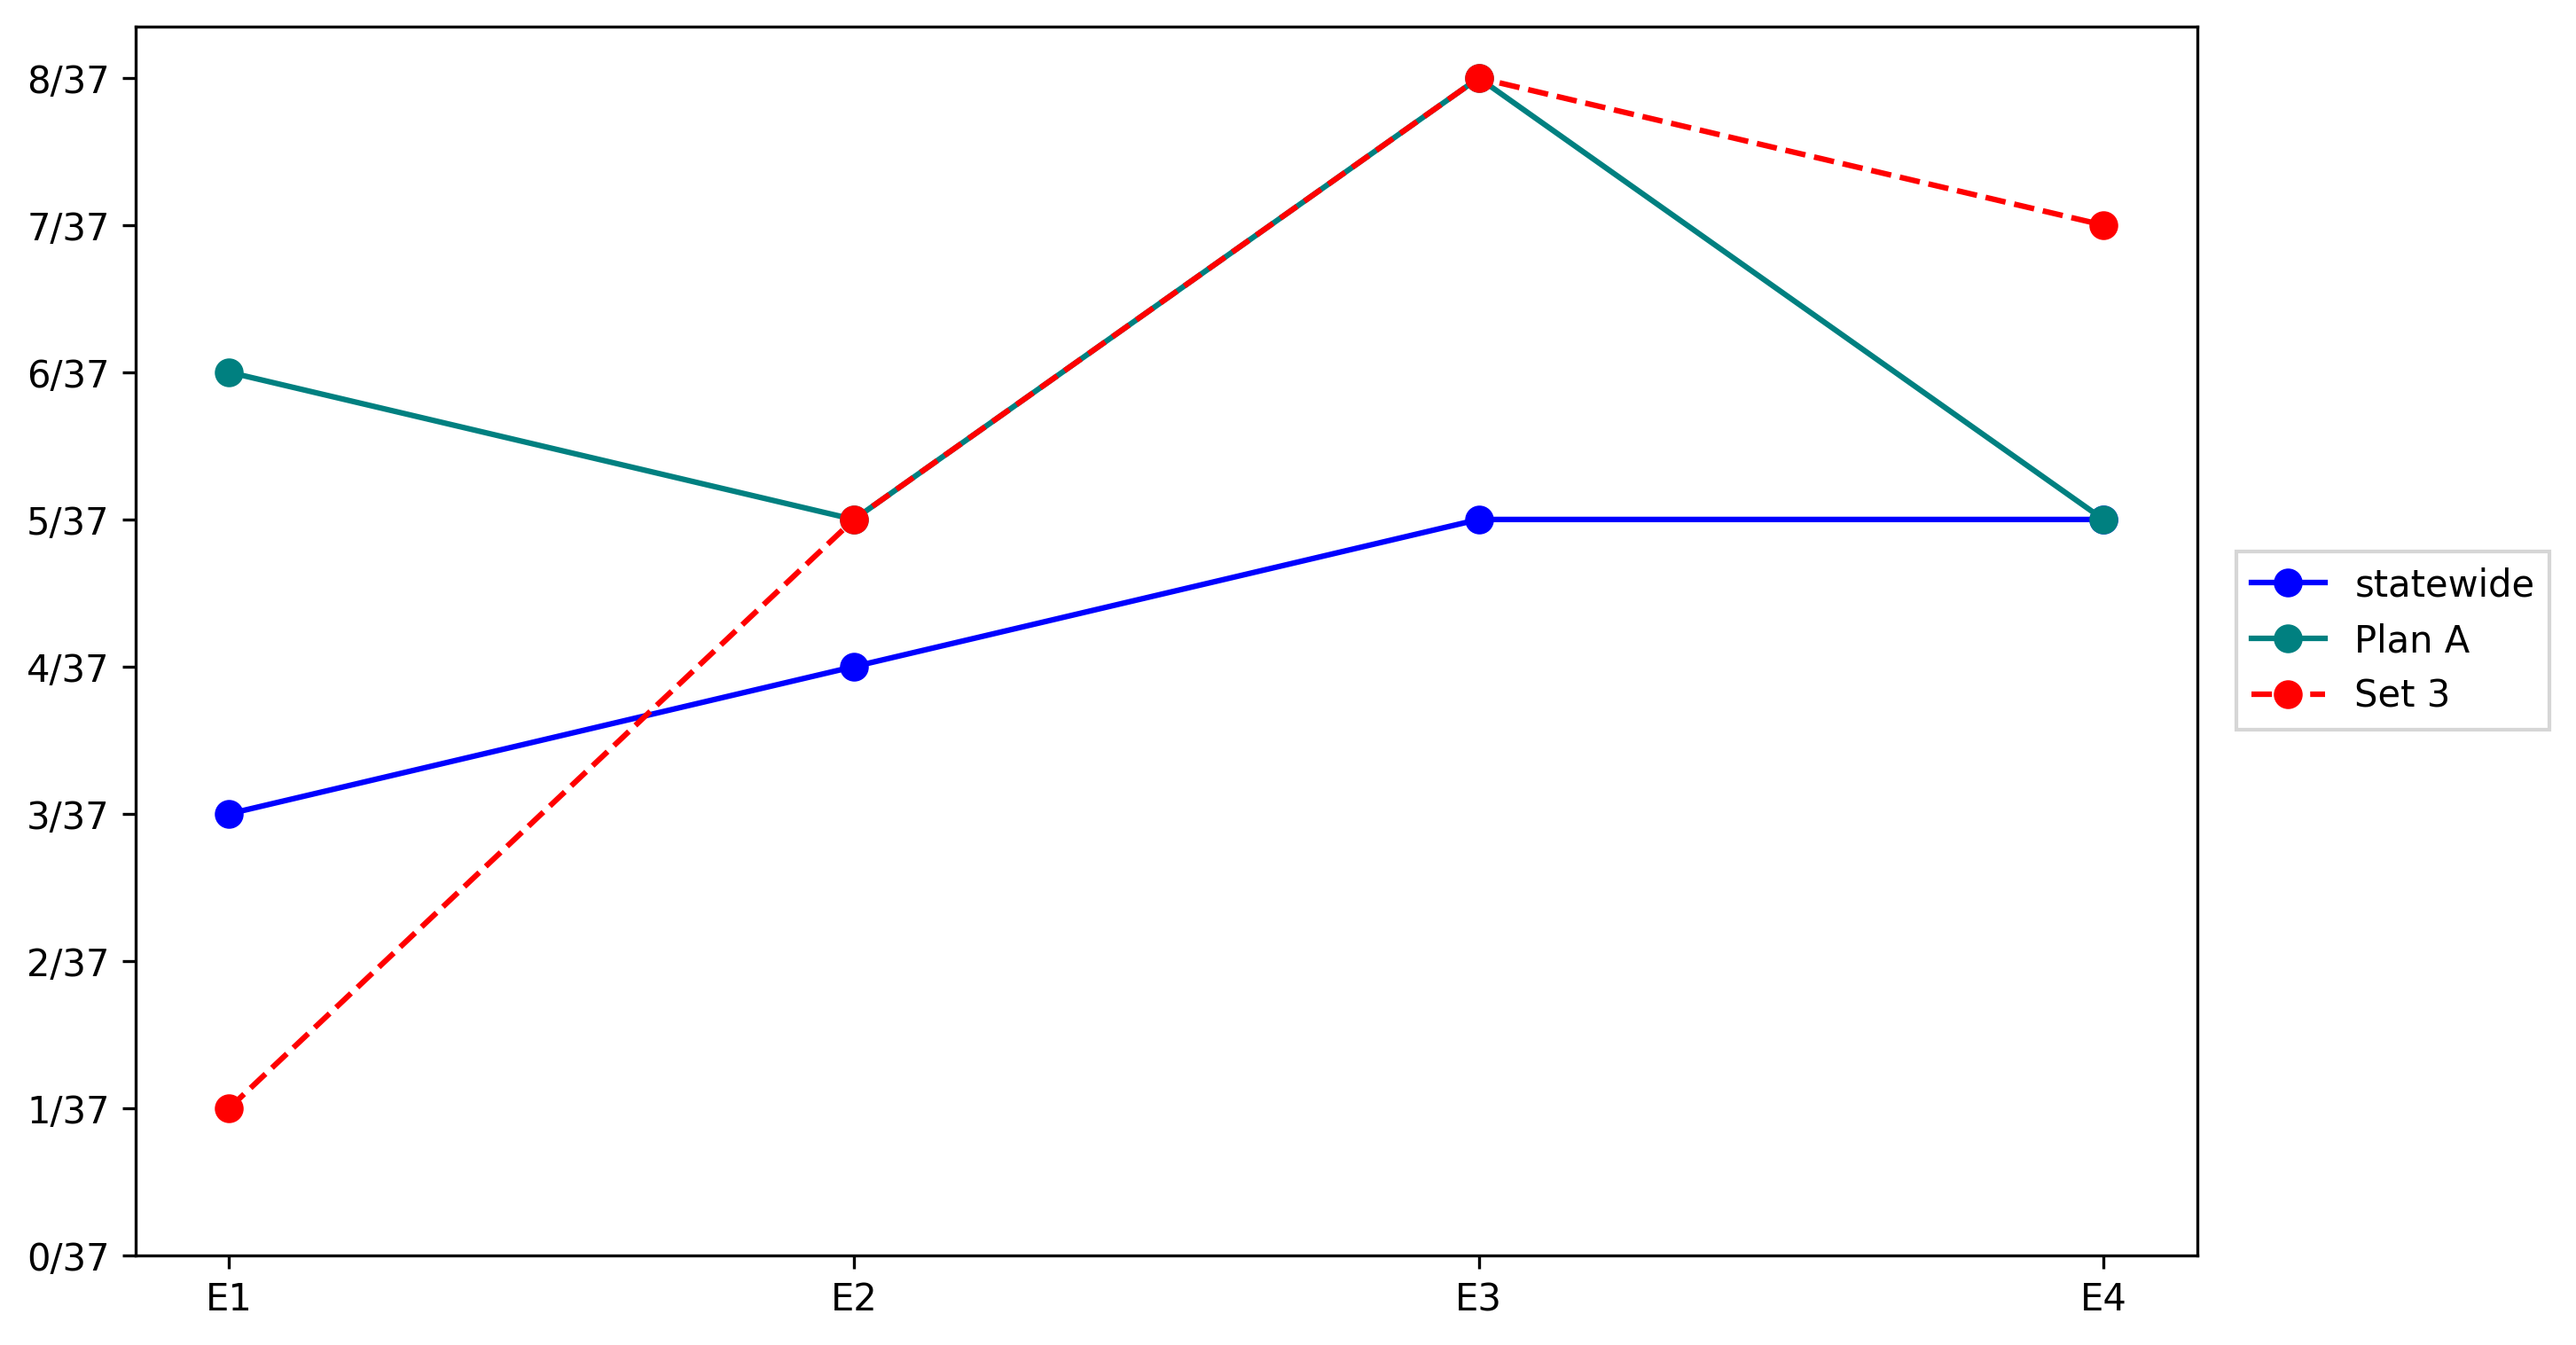

In [ ]:
from gerrytools.plotting.sealevel import SeaLevel

from fractions import Fraction


def seatshare_map(num_districts, **seats_by_election):
    return {k: v / num_districts for k, v in seats_by_election.items()}


scores1 = {
    "statewide": seatshare_map(num_districts, E1=3, E2=4, E3=5, E4=5),
    "Plan A":    seatshare_map(num_districts, E1=6, E2=5, E3=8, E4=5),
    "Plan B":    seatshare_map(num_districts, E1=1, E2=5, E3=8, E4=7),
}


sea = SeaLevel(include_legend=True)
sea.add_sealevel_set(scores1["statewide"], linecolor="blue", name="statewide")
sea.add_sealevel_set(scores1["Plan A"], linecolor="teal", name="Plan A")
sea.add_sealevel_set(scores1["Plan B"], linecolor="red", linestyle="--")
sea.format_ylabels_as_fractions(denominator=num_districts, maximum_numerator=8)

sea.show()